# 🎙️ Feedback Amplifier Activity: Microphone → Amplifier → Speaker



## Objective

In this activity, you will explore how a **common-emitter (CE) amplifier with shunt feedback** can be used to process an audio signal.

To start, click the run all button on the top bar. Observe that different plots are generated about the circuit as the notebook runs. You can make changes in the circuit parameters cell box and it will reflect in the simulations.

The notebook generates a small audio signal. This signal is amplified by the single-ended shunt-shunt amplifier shown.

Currently, the signal is amplified WITHOUT shunt feedback ($R_F \rightarrow \infty$).

## Circuit

The circuit is a shunt-shunt feedback CE amplifier.
However, the input is a voltage with $R_S=1k\Omega$ and $C_i=10uF$.

To analyze this, you must do the following:
1. First, remove $V_i$, $R_S$, and $C_i$ then analyze as a shunt-shunt feedback CE with an input $I_i$.
2. Then, add back the $V_i$, $R_S$, and $C_i$ and analyze against the new closed-loop two-port of the shunt-shunt feedback amplifier.
3. From analyzing (2), you obtain the overall voltage-voltage gain $A_v$. Use this to design the latter circuit.

The circuit starts with an $R_B$ to demonstrate a non-feedback amplifier mode, but I suggest making it a high value to effectively remove it.

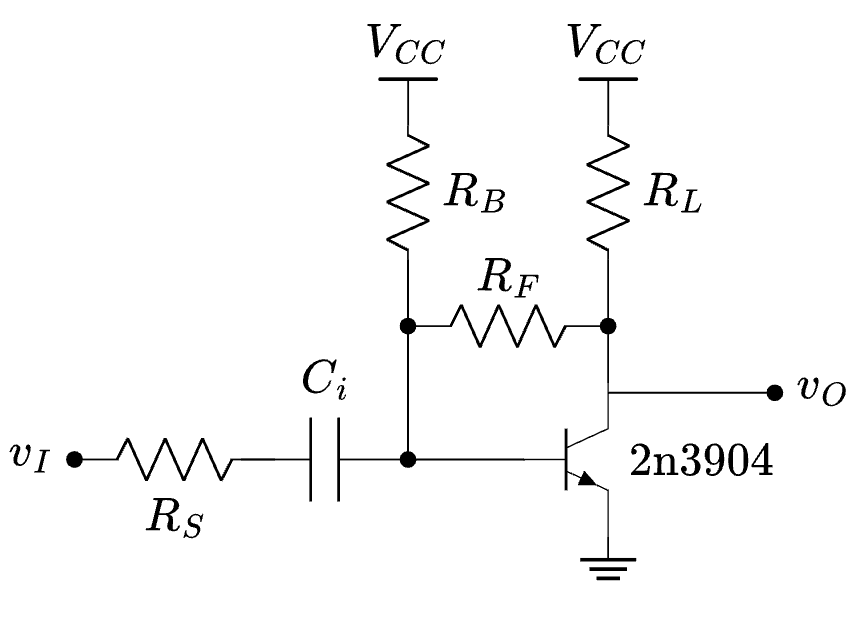

## Log-spectral Distance (LSD)

LSD is a measurement of the difference in frequency content between two signals.

A value of $\text{LSD} > \text{10dB}$ is already intense harmonic distortion and is audible.

Observe at the end of the current notebook that the audio signal amplified by the current setup has intense harmonic distortion.

## Instructions

Your goal is to redesign the component values of the amplifier to get this total $\text{LSD}$ below $10dB$, while maintaining a baseband gain of above 30dB.
Look at the "flat region" of the AC response to see this baseband gain.

You may edit cell 2 to set all of the component values. Do not edit any other cell.

After designing a proper amplifier with the following properties:

- $\text{LSD} < \text{10dB}$
- baseband gain $A_{v,overall} = \text{20dB}\pm 1$

### __answer the questions in cell 3 by editing it__.

In [93]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          EDIT THIS CELL — Amplifier Component Values            ║
# ╚══════════════════════════════════════════════════════════════════╝

Rf  = 47e20   # Shunt feedback resistance -- Practically infinite at the start
Rc  = 1.8e3      # Collector resistance
Rb  = 400e3     # Base resistance -- Turn infinite (10e20 should be fine) before you start designing

# Questions

1. Why does the first circuit fail the LSD test? Why is the output very distorted?

[Place answers here]

2. Why does putting the amplifier in feedback get the LSD to be under 10dB?

[Place answers here]

3. What is the approximate gain equation you used for the overall amplifier?

[Place answers here]

### Once you have done all the questions, go to `File > Download > .ipynb` and download your modified notebook. Rename it to `lastname_studentnumber.ipynb`. Submit it in UVLe for checking.

In [94]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import subprocess, tempfile, os, re, warnings
from scipy.interpolate import interp1d
from IPython.display import Audio, display

warnings.filterwarnings('ignore')
print("Libraries loaded ✓")

!apt-get install ngspice -y > /dev/null


Libraries loaded ✓


Audio signal: 2000 samples | 250 ms | 8000 Hz
Notes: C4 → E4 → G4 → C5 (C-major arpeggio)


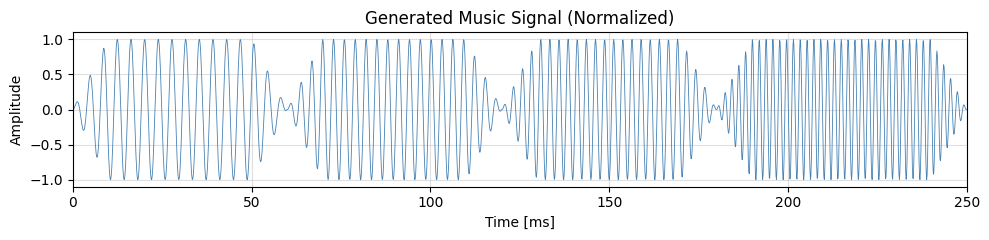


Original audio:


In [95]:
# @title
# ── Audio parameters ──────────────────────────────────────────────────────────
Fs      = 8000     # sample rate [Hz]
t_total = 0.25     # total duration [s]
t       = np.arange(int(Fs * t_total)) / Fs   # time axis

# ── Condenser mic signal amplitude ──────────────────────────────────────────
Vmic = 0.05  # Microphone peak amplitude  [V]

# ── Compose a short C-major arpeggio (C4 → E4 → G4 → C5) ────────────────────
notes = [
    (261.63, 0.00, 0.06),   # C4
    (329.63, 0.06, 0.12),   # E4
    (392.00, 0.12, 0.18),   # G4
    (523.25, 0.18, 0.25),   # C5
]

audio = np.zeros_like(t)
for freq, t_on, t_off in notes:
    mask    = (t >= t_on) & (t < t_off)
    t_note  = t[mask] - t_on
    fade    = max(1, int(0.010 * Fs))          # 10 ms fade in/out
    env     = np.ones(mask.sum())
    env[:fade]  = np.linspace(0, 1, fade)
    env[-fade:] = np.linspace(1, 0, fade)
    audio[mask] = env * np.sin(2 * np.pi * freq * t_note)

audio /= np.max(np.abs(audio) + 1e-12)        # normalize to ±1

print(f"Audio signal: {len(t)} samples | {t_total*1000:.0f} ms | {Fs} Hz")
print(f"Notes: C4 → E4 → G4 → C5 (C-major arpeggio)")

plt.figure(figsize=(10, 2.5))
plt.plot(t * 1000, audio, linewidth=0.6, color='steelblue')
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('Generated Music Signal (Normalized)')
plt.xlim(0, t_total * 1000); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print("\nOriginal audio:")
display(Audio(audio, rate=Fs, normalize=False))


In [96]:
# @title
# ── Condenser Microphone Model ────────────────────────────────────────────────
# A condenser mic converts sound pressure to a small AC voltage.
# We scale the normalized audio to ±Vmic volts (peak).
V_mic = Vmic * audio                 # mic voltage signal [V]
print(f"Mic signal: ±{Vmic*1000:.0f} mV peak, RMS = {np.sqrt(np.mean(V_mic**2))*1000:.1f} mV")

# ── BJT Models (ngspice parameters) ───────────────────────────────────────────
BJT_MODEL = """
.model 2N3904 NPN(IS=4.639E-15 NF=0.9995 ISE=2.091E-14 NE=1.6 BF=160.1 IKF=0.12
+                 VAF=98.69 NR=1.001 ISC=3.257E-12 NC=1.394 BR=5.944 IKR=0.06
+                 VAR=19.29 RB=1 IRB=1E-6 RBM=1 RE=0.3614 RC=1.755 XTB=0
+                 EG=1.11 XTI=3 CJE=5.631E-12 VJE=0.7002 MJE=0.3385
+                 TF=3.001E-10 XTF=27 VTF=1.461 ITF=0.2723 PTF=0 CJC=4.949E-12
+                 VJC=0.5969 MJC=0.1928 XCJC=0.864 TR=9.4E-8 CJS=0 VJS=0.75
+                 MJS=0.333 FC=0.5582)
"""

Mic signal: ±50 mV peak, RMS = 31.4 mV


In [97]:
# @title
import subprocess, tempfile, os


# Some reusable values

Rin = 1e3
Re = 0
VCC = 9

# ── Build PWL string: pure AC mic signal (no DC offset — bias is in circuit) ──
# V(Vbase) = V(Vref) + Vin  →  Vin = V_mic (centred on 0 V)
pwl_str = " ".join(f"{t[i]:.7e} {V_mic[i]:.7f}" for i in range(len(t)))
pwl_str += f" {t[-1] + 1/Fs:.7e} {V_mic[-1]:.7f}"

# ── Simulation parameters ─────────────────────────────────────────────────────
Vac_src      = 1e-3
Vin_sw_start = 0
Vin_sw_stop  = VCC
Vin_sw_step  = 0.01

tstep  = 1 / Fs
tstop  = t_total + tstep

# ── Output file paths ─────────────────────────────────────────────────────────
sim_dir   = tempfile.mkdtemp()
dc_file   = os.path.join(sim_dir, 'dc_out.txt')
tran_file = os.path.join(sim_dir, 'tran_out.txt')
ac_file   = os.path.join(sim_dir, 'ac_out.txt')
cir_dc    = os.path.join(sim_dir, 'dc_sweep.cir')
cir_main  = os.path.join(sim_dir, 'main.cir')

# ── 1. DC Sweep Netlist (Direct base drive) ───────────────────────────────────
netlist_dc = f"""* CE Amplifier DC Sweep
{BJT_MODEL}
Vcc VCC 0 DC {VCC}
Rc VCC Vout {Rc}
Q1 Vout Vb1 0 2N3904
Vtestb1 Vb1 0 DC 0
Rin Vin Vb1 {Rin}
Rf Vout Vb1 {Rf}
Rb VCC Vb1 {Rb}

.control
  dc Vtestb1 {Vin_sw_start} {Vin_sw_stop} {Vin_sw_step}
  wrdata {dc_file} v(vout) v(vb1)
.endc
.end
"""

# ── 2. AC/Transient Netlist (Capacitively coupled) ────────────────────────────
netlist_main = f"""* CE Amplifier with Rf/Cf Shunt Feedback and Re Degen
{BJT_MODEL}
Vcc VCC 0 DC {VCC}
Rc VCC Vout {Rc}
Q1 Vout Vb1 0 2N3904
Vin Vsig 0 DC 0 AC {Vac_src} PWL({pwl_str})
Cin Vsig Vcinrin 10u
Rin Vcinrin Vb1 {Rin}
Rf Vout Vb1 {Rf}
Rb VCC Vb1 {Rb}

.control
  op
  show Q1
  print v(vout) v(vb1)
  echo OP_DONE
  tran {tstep:.6e} {tstop:.6f}
  wrdata {tran_file} v(vb1) v(vout)
  echo TRAN_DONE
  ac dec 100 10 100Meg
  wrdata {ac_file} v(vout)
  echo AC_DONE
.endc
.end
"""

with open(cir_dc, 'w') as f: f.write(netlist_dc)
with open(cir_main, 'w') as f: f.write(netlist_main)

print("Running DC Sweep...")
subprocess.run(['ngspice', '-b', cir_dc], capture_output=True, text=True)

print("Running Transient and AC Analysis...")
result = subprocess.run(['ngspice', '-b', cir_main], capture_output=True, text=True, timeout=300)
ngspice_out = result.stdout + result.stderr

if 'OP_DONE' in ngspice_out:
    op_part = ngspice_out.split('OP_DONE')[0]
    print("\n--- Operating Point (OP) Analysis ---")
    print(op_part.strip())
    print("-------------------------------------\n")

print("Simulation complete ✓")

Running DC Sweep...
Running Transient and AC Analysis...

--- Operating Point (OP) Analysis ---
No compatibility mode selected!


Circuit: * ce amplifier with rf/cf shunt feedback and re degen

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


No. of Data Rows : 1
 BJT: Bipolar Junction Transistor
     device                    q1
      model                2n3904
         ic            0.00312294
         ib           2.07346e-05
         ie           -0.00314367
        vbe              0.705004
        vbc              -2.66709
         gm               0.11759
        gpi           0.000794452
        gmu           1.00001e-12
         gx                     1
         go           3.19482e-05
        cpi           4.53873e-11
        cmu           3.08159e-12
        cbx           4.85065e-13
       csub                     0

v(vout) = 3.378713e+00
v(vb1) = 7.061612e-01
-------------------------------------

Simulation complete ✓


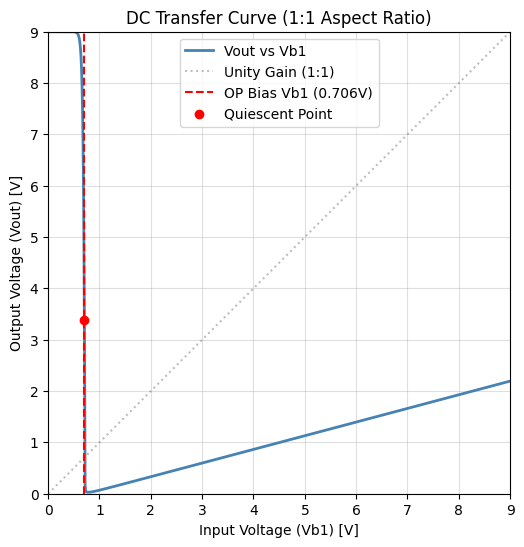

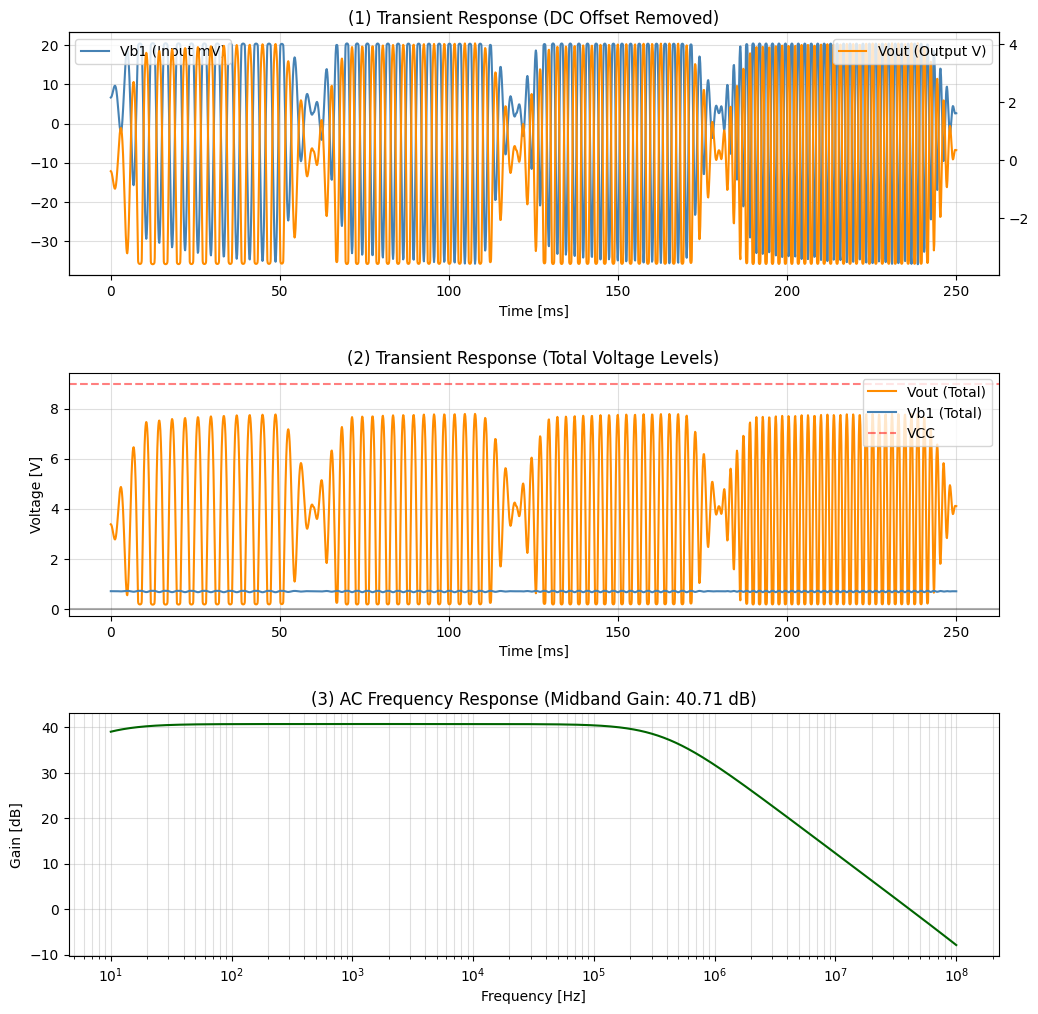

In [98]:
# @title
# ── Parser for ngspice wrdata output ─────────────────────────────────────────
def parse_wrdata(filepath, n_vars, is_complex=False):
    rows = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line and not line.startswith('*'):
                try:
                    rows.append([float(v) for v in line.split()])
                except ValueError:
                    pass
    data = np.array(rows)
    if is_complex:
        return (data[:, 0],) + tuple(data[:, 1 + 2*i] + 1j * data[:, 2 + 2*i] for i in range(n_vars))
    else:
        x = data[:, 0]
        vecs = [data[:, 1 + 2*i] for i in range(n_vars)]
        return (x,) + tuple(vecs)

# ── Load simulation results ───────────────────────────────────────────────────
dc_raw = parse_wrdata(dc_file, 2, is_complex=False)
dc_vin = dc_raw[0]
dc_vout = dc_raw[1]
dc_vb1 = dc_raw[2]

tr_t, tr_vb1, tr_vout = parse_wrdata(tran_file, 2, is_complex=False)

ac_data = parse_wrdata(ac_file, 1, is_complex=True)
ac_f = ac_data[0]
ac_vout_c = ac_data[1]
ac_gain_dB = 20 * np.log10(np.abs(ac_vout_c) / Vac_src + 1e-12)

# ── Extract actual Bias Point from ngspice OP output ──────────────────────────
def get_op_value(output, label):
    match = re.search(fr"{label}\s*=\s*([0-9\.e\+\-]+)", output, re.IGNORECASE)
    return float(match.group(1)) if match else 0.0

vb1_op = get_op_value(ngspice_out, "v\\(vb1\\)")
vout_op = get_op_value(ngspice_out, "v\\(vout\\)")

# ── 1. Separate DC Transfer Figure (1:1 Ratio) ────────────────────────────────
plt.figure(figsize=(6, 6))
plt.plot(dc_vin, dc_vout, color='steelblue', linewidth=2, label='Vout vs Vb1')
plt.plot([0, VCC], [0, VCC], color='gray', linestyle=':', alpha=0.5, label='Unity Gain (1:1)')
# Plotting the operating point found in simulation
plt.axvline(vb1_op, color='red', linestyle='--', label=f'OP Bias Vb1 ({vb1_op:.3f}V)')
plt.scatter([vb1_op], [vout_op], color='red', zorder=5, label='Quiescent Point')

plt.xlabel('Input Voltage (Vb1) [V]')
plt.ylabel('Output Voltage (Vout) [V]')
plt.title('DC Transfer Curve (1:1 Aspect Ratio)')
plt.xlim(0, VCC); plt.ylim(0, VCC)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, alpha=0.4); plt.legend()
plt.show()

# ── 2. Main Analysis Figure ───────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 12))
gs  = gridspec.GridSpec(3, 1, hspace=0.4)

# Subplot 1: Transient (AC Centered)
ax1 = fig.add_subplot(gs[0])
ax1_twin = ax1.twinx()
tr_vbase_ac = (tr_vb1 - np.mean(tr_vb1)) * 1e3
tr_vout_ac = (tr_vout - np.mean(tr_vout))
ax1.plot(tr_t * 1e3, tr_vbase_ac, color='steelblue', label='Vb1 (Input mV)')
ax1_twin.plot(tr_t * 1e3, tr_vout_ac, color='darkorange', label='Vout (Output V)')
ax1.set_title('(1) Transient Response (DC Offset Removed)')
ax1.set_xlabel('Time [ms]'); ax1.grid(True, alpha=0.4)
ax1.legend(loc='upper left'); ax1_twin.legend(loc='upper right')

# Subplot 2: Transient (Full Signal)
ax2 = fig.add_subplot(gs[1])
ax2.plot(tr_t * 1e3, tr_vout, color='darkorange', label='Vout (Total)')
ax2.plot(tr_t * 1e3, tr_vb1, color='steelblue', label='Vb1 (Total)')
ax2.axhline(VCC, color='red', linestyle='--', alpha=0.5, label='VCC')
ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
ax2.set_title('(2) Transient Response (Total Voltage Levels)')
ax2.set_xlabel('Time [ms]'); ax2.set_ylabel('Voltage [V]')
ax2.grid(True, alpha=0.4); ax2.legend(loc='upper right')

# Subplot 3: AC
ax3 = fig.add_subplot(gs[2])
ax3.semilogx(ac_f, ac_gain_dB, color='darkgreen')
midband_gain = ac_gain_dB[len(ac_gain_dB)//2]
ax3.set_xlabel('Frequency [Hz]'); ax3.set_ylabel('Gain [dB]')
ax3.set_title(f'(3) AC Frequency Response (Midband Gain: {midband_gain:.2f} dB)')
ax3.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

Output signal peak-to-peak : 7809.0 mV  (input ±50 mV)
Log-Spectral Distance      : 23.51 dB  (0 = perfect, >3 dB = audible, >10 dB = severe)


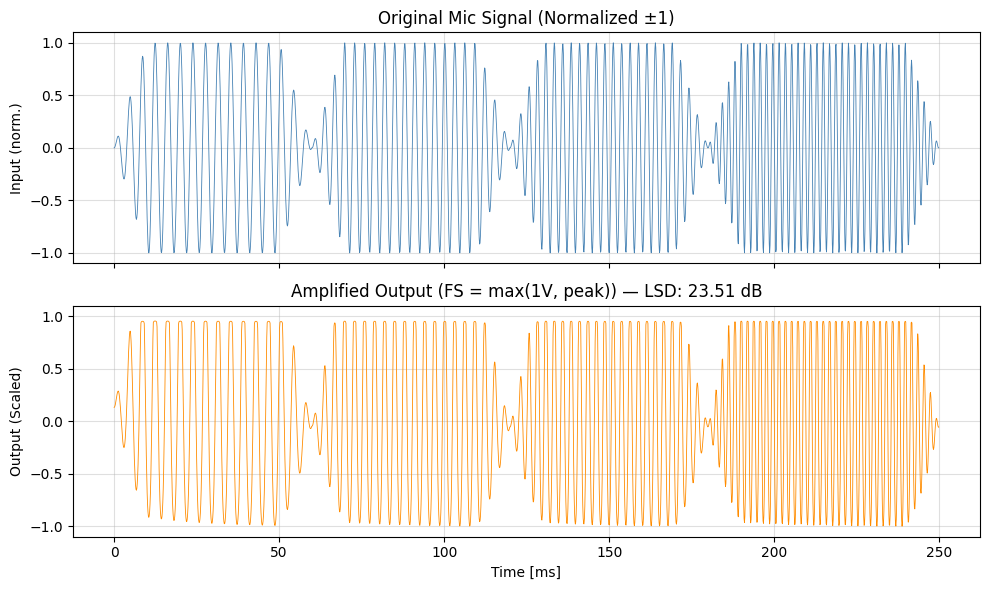


🎵 Original audio (input source):



🔊 Amplified audio (circuit output):


In [99]:
# @title
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from scipy.signal.windows import flattop
import matplotlib.pyplot as plt

# ── Interpolate transient output onto uniform audio grid ─────────────────────
t_uniform = np.arange(int(Fs * t_total)) / Fs
t_clamp   = np.clip(t_uniform, tr_t[0], tr_t[-1])

interp_vout  = interp1d(tr_t, tr_vout, kind='linear', bounds_error=False,
                         fill_value=(tr_vout[0], tr_vout[-1]))
vout_uniform = interp_vout(t_clamp)

# ── Remove DC bias and Conditional Normalization ──────────────────────────────
audio_out   = -(vout_uniform - np.mean(vout_uniform))
peak_val    = np.max(np.abs(audio_out))
norm_factor = max(0.5, peak_val)
audio_out_norm = audio_out / norm_factor

# ── Log-Spectral Distance ─────────────────────────────────────────────────────
def log_spectral_distance(ref_signal, test_signal, fs, freq_range=(20, 20000)):

    assert len(ref_signal) == len(test_signal), "Signals must be the same length"
    N = len(ref_signal)

    window   = flattop(N)
    win_norm = np.sqrt(np.mean(window ** 2))   # RMS-normalize so power is comparable

    ref_spectrum  = np.abs(fft(ref_signal  * window / win_norm))
    test_spectrum = np.abs(fft(test_signal * window / win_norm))

    freqs    = fftfreq(N, 1 / fs)
    pos_mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    freqs, ref_spectrum, test_spectrum = (
        freqs[pos_mask], ref_spectrum[pos_mask], test_spectrum[pos_mask]
    )

    # Normalize each spectrum to its own peak → compare shape, not level
    ref_spectrum  = ref_spectrum  / (np.max(ref_spectrum)  + 1e-12)
    test_spectrum = test_spectrum / (np.max(test_spectrum) + 1e-12)

    # Floor at -80 dB to avoid log(0) blowing up on silent bins
    floor = 10 ** (-80 / 20)
    log_ref  = 20 * np.log10(np.maximum(ref_spectrum,  floor))
    log_test = 20 * np.log10(np.maximum(test_spectrum, floor))

    lsd_db = np.sqrt(np.mean((log_ref - log_test) ** 2))
    return lsd_db

# ── Compute LSD on the last-note segment ─────────────────────────────────────
start_idx, end_idx = int(0.18 * Fs), int(0.24 * Fs)

# Both signals normalized to ±1 peak for shape-only comparison
ref_seg  = audio[start_idx:end_idx]
test_seg = (audio_out / peak_val)[start_idx:end_idx]

# Trim to equal length in case of rounding
min_len  = min(len(ref_seg), len(test_seg))
lsd_val  = log_spectral_distance(ref_seg[:min_len], test_seg[:min_len], Fs)

print(f"Output signal peak-to-peak : {peak_val*2000:.1f} mV  (input ±{Vmic*1000:.0f} mV)")
print(f"Log-Spectral Distance      : {lsd_val:.2f} dB  (0 = perfect, >3 dB = audible, >10 dB = severe)")

# ── Side-by-side comparison plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t * 1e3, audio, linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Input (norm.)')
axes[0].set_title('Original Mic Signal (Normalized ±1)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_uniform * 1e3, audio_out_norm, linewidth=0.6, color='darkorange')
axes[1].set_ylabel('Output (Scaled)')
axes[1].set_title(f'Amplified Output (FS = max(1V, peak)) — LSD: {lsd_val:.2f} dB')
axes[1].set_xlabel('Time [ms]')
axes[1].grid(True, alpha=0.4)
axes[1].set_ylim([-1.1, 1.1])

plt.tight_layout()
plt.show()

# ── Playback ──────────────────────────────────────────────────────────────────
print("\n🎵 Original audio (input source):")
display(Audio(audio, rate=Fs, normalize=False))

print("\n🔊 Amplified audio (circuit output):")
display(Audio(audio_out_norm, rate=Fs, normalize=False))